# Zusammenführen der CSV Dateien

In [1]:
import pandas as pd

combined_df = pd.read_csv("combined_data_Diabetes.csv")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# Ermnitteln der Anzahl von kategorischen und numerischen Features

In [2]:
# Definieren der Feature Typen
feature_types = {
    'Diabetes_binary': 'kategorisch',
    'HighBP': 'kategorisch',
    'HighChol': 'kategorisch',
    'CholCheck': 'kategorisch',
    'BMI': 'numerisch',
    'Smoker': 'kategorisch',
    'Stroke': 'kategorisch',
    'HeartDiseaseorAttack': 'kategorisch',
    'PhysActivity': 'kategorisch',
    'Fruits': 'kategorisch',
    'Veggies': 'kategorisch',
    'HvyAlcoholConsump': 'kategorisch',
    'AnyHealthcare': 'kategorisch',
    'NoDocbcCost': 'kategorisch',
    'GenHlth': 'numerisch',
    'MentHlth': 'numerisch',
    'PhysHlth': 'numerisch',
    'DiffWalk': 'kategorisch',
    'Sex': 'kategorisch',
    'Age': 'numerisch',
    'Education': 'numerisch',
    'Income': 'numerisch'
}

In [3]:
df = combined_df

df['num_num_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
df['num_cat_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

In [4]:
df.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,latitude,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features
0,2023-11-04T11:45:15,DecisionTree_21_features_reduced_by_0_percent0,cb0442e1-7386-4cd1-af0a-4c1d7005b4a7,1.135227,3.229204e-06,0.000003,42.5,0.0,4.754379,0.000013,...,38.894,12.678345,machine,N,1.0,21,0,"PhysHlth, Age, Fruits, Smoker, HvyAlcoholConsu...",7,14
1,2023-11-04T11:45:19,DecisionTree_21_features_reduced_by_20_percent0,395b46dc-58f5-4190-8c7c-45a7542dc51d,1.305288,3.728614e-06,0.000003,42.5,0.0,4.754379,0.000015,...,38.894,12.678345,machine,N,1.0,21,20,"PhysHlth, Age, Fruits, Smoker, HvyAlcoholConsu...",7,14
2,2023-11-04T11:45:21,DecisionTree_21_features_reduced_by_40_percent0,76230c4e-f503-4a89-af61-5c6ce143a9ce,0.630450,1.790142e-06,0.000003,42.5,0.0,4.754379,0.000007,...,38.894,12.678345,machine,N,1.0,21,40,"PhysHlth, Age, Fruits, Smoker, HvyAlcoholConsu...",7,14
3,2023-11-04T11:45:24,DecisionTree_21_features_reduced_by_60_percent0,b87efce8-2422-4771-9af5-4f7cb5331a39,0.397343,1.123763e-06,0.000003,42.5,0.0,4.754379,0.000005,...,38.894,12.678345,machine,N,1.0,21,60,"PhysHlth, Age, Fruits, Smoker, HvyAlcoholConsu...",7,14
4,2023-11-04T11:45:26,DecisionTree_21_features_reduced_by_80_percent0,88c25a98-1701-4604-99ed-ebe591de3115,0.174671,4.809273e-07,0.000003,42.5,0.0,4.754379,0.000002,...,38.894,12.678345,machine,N,1.0,21,80,"PhysHlth, Age, Fruits, Smoker, HvyAlcoholConsu...",7,14


In [5]:
# Ermitteln, wie of ein feature vorgekommen ist

df['feature_names'] = df['feature_names'].str.split(', ')

feature_counts = {}

# Iteriere über jede Zeile des DataFrames
for index, row in df.iterrows():
    features = row['feature_names']
    if isinstance(features, list):
        for feature in features:
            if feature in feature_counts:
                feature_counts[feature] += 1
            else:
                feature_counts[feature] = 1


feature_counts_df = pd.DataFrame(list(feature_counts.items()), columns=['Feature', 'Count'])

In [6]:
feature_counts

{'PhysHlth': 3225,
 'Age': 3285,
 'Fruits': 3390,
 'Smoker': 3310,
 'HvyAlcoholConsump': 3350,
 'HeartDiseaseorAttack': 3165,
 'MentHlth': 3385,
 'Veggies': 3330,
 'HighChol': 3405,
 'Sex': 3305,
 'GenHlth': 3285,
 'Education': 3235,
 'CholCheck': 3390,
 'Stroke': 3080,
 'AnyHealthcare': 3325,
 'NoDocbcCost': 3250,
 'DiffWalk': 3330,
 'HighBP': 3225,
 'PhysActivity': 3305,
 'Income': 3405,
 'BMI': 3320}

# Häufigkeit der Features auf Zufälligkeit testen

In [7]:
import numpy as np
from scipy.stats import anderson, shapiro
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Extrahiere die beobachteten Werte
observed_data = list(feature_counts.values())

# Führe den Anderson-Darling-Test durch
result_anderson = anderson(observed_data)
alpha = 0.05  # Signifikanzniveau

# Führe den Shapiro-Wilk-Test durch
statistic_shapiro, p_value_shapiro = shapiro(observed_data)

# Histogramm
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(observed_data, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram der Daten')

# Q-Q-Plot für den Shapiro-Wilk-Test
plt.subplot(1, 2, 2)
sm.qqplot(np.array(observed_data), line='s', color='lightcoral')
plt.title('Q-Q-Plot für Shapiro-Wilk-Test')

plt.show()

# Zeige die Testergebnisse und Interpretation
print(f"Anderson-Darling-Statistik: {result_anderson.statistic}")
print(f"Kritische Werte für Anderson-Darling-Test: {result_anderson.critical_values}")
if result_anderson.statistic > result_anderson.critical_values[2]:
    print("Anderson-Darling-Test: Die Daten weichen signifikant von einer Normalverteilung ab.")
else:
    print("Anderson-Darling-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.")

print(f"Shapiro-Wilk-Statistik: {statistic_shapiro}")
print(f"P-Wert für Shapiro-Wilk-Test: {p_value_shapiro}")
if p_value_shapiro < alpha:
    print("Shapiro-Wilk-Test: Die Daten weichen signifikant von einer Normalverteilung ab.")
else:
    print("Shapiro-Wilk-Test: Die Daten zeigen keine signifikante Abweichung von einer Normalverteilung.")

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
df.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,latitude,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features
0,2023-11-04T11:45:15,DecisionTree_21_features_reduced_by_0_percent0,cb0442e1-7386-4cd1-af0a-4c1d7005b4a7,1.135227,3.229204e-06,0.000003,42.5,0.0,4.754379,0.000013,...,38.894,12.678345,machine,N,1.0,21,0,"[PhysHlth, Age, Fruits, Smoker, HvyAlcoholCons...",7,14
1,2023-11-04T11:45:19,DecisionTree_21_features_reduced_by_20_percent0,395b46dc-58f5-4190-8c7c-45a7542dc51d,1.305288,3.728614e-06,0.000003,42.5,0.0,4.754379,0.000015,...,38.894,12.678345,machine,N,1.0,21,20,"[PhysHlth, Age, Fruits, Smoker, HvyAlcoholCons...",7,14
2,2023-11-04T11:45:21,DecisionTree_21_features_reduced_by_40_percent0,76230c4e-f503-4a89-af61-5c6ce143a9ce,0.630450,1.790142e-06,0.000003,42.5,0.0,4.754379,0.000007,...,38.894,12.678345,machine,N,1.0,21,40,"[PhysHlth, Age, Fruits, Smoker, HvyAlcoholCons...",7,14
3,2023-11-04T11:45:24,DecisionTree_21_features_reduced_by_60_percent0,b87efce8-2422-4771-9af5-4f7cb5331a39,0.397343,1.123763e-06,0.000003,42.5,0.0,4.754379,0.000005,...,38.894,12.678345,machine,N,1.0,21,60,"[PhysHlth, Age, Fruits, Smoker, HvyAlcoholCons...",7,14
4,2023-11-04T11:45:26,DecisionTree_21_features_reduced_by_80_percent0,88c25a98-1701-4604-99ed-ebe591de3115,0.174671,4.809273e-07,0.000003,42.5,0.0,4.754379,0.000002,...,38.894,12.678345,machine,N,1.0,21,80,"[PhysHlth, Age, Fruits, Smoker, HvyAlcoholCons...",7,14


# Korrelationen

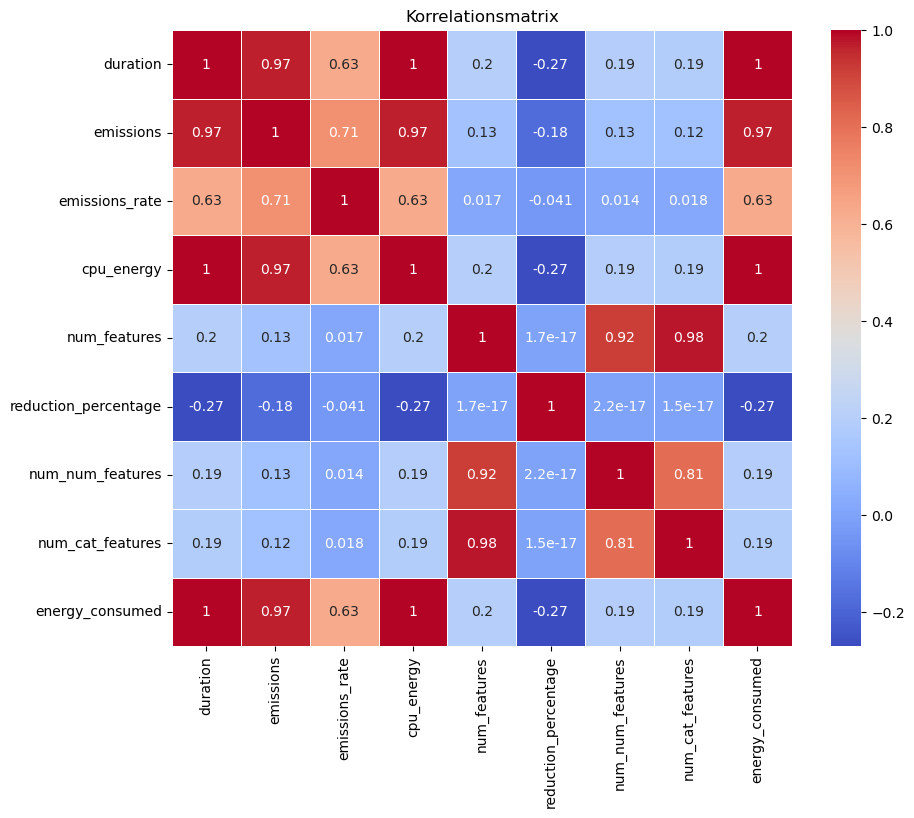

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Spalten definieren, welche behalten werden sollen
selected_columns = ['duration', 'emissions', 'emissions_rate', 'cpu_energy', 'num_features', 'reduction_percentage', 'num_num_features', 'num_cat_features', 'energy_consumed']

# Erstelle die Korrelationsmatrix nur für die ausgewählten Spalten
correlation_matrix = df[selected_columns].corr()

# Erstelle eine Heatmap der Korrelationsmatrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korrelationsmatrix')
plt.show()

Ludwig AI

In [ ]:
!python -m pip install git+https://github.com/ludwig-ai/ludwig.git --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
eco2ai 0.3.9 requires pandas<=1.4.3,>=1.4.0; python_version >= "3.8", but you have pandas 1.5.3 which is incompatible.
